In [549]:
import subprocess
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import scipy.optimize as so
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

from math import sqrt
import subprocess
from scipy.optimize import curve_fit
sns.set()
sns.set_context('paper', font_scale=1.2)

In [551]:
#######################################################################################################################################################################################################
#######################################################################################################################################################################################################
# Path: Newsimulation.ipynb
#######################################################################################################################################################################################################
#######################################################################################################################################################################################################

# Parse EnergyPlus datetime string
energyplus_install_dir=r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\EnergyPlusV9-6-0"
output_relative_directory =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation"
#idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\SmallOffice.idf"
#idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\smalloffice_before_bang_bang_edit_working_25_august\changed\SmallOffice.idf"



#####SKY TEMPERATURE PART
#idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\smalloffice_before_bang_bang_edit_working_25_august\changed\skytemperature\SmallOffice.idf"
idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\smalloffice_before_bang_bang_edit_working_25_august\changed\SmallOffice.idf"

#epw_relative_filepath =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\USA_NY_Albany.Intl.AP.725180_US.Normals.1991-2020.epw"
epw_relative_filepath =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\USA_NY_Albany.Intl.AP.725180_TMY3.epw"
#epw_relative_filepath =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\USA_FL_Tallahassee.Intl.AP.722140_TMY3.epw"
#epw_relative_filepath =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\Final\validation\USA_FL_Tallahassee.Intl.AP.722140_US.Normals.1991-2020.epw"
#epw_relative_filepath =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\USA_CO_Denver.Intl.AP.725650_TMY3.epw"
def run_command(cmd_string, capture_output=False):
    # sourcery skip: raise-specific-error
    result = subprocess.run(cmd_string, capture_output=capture_output)
    if result.returncode != 0:
        raise Exception(f'Command failed with return code: {result.returncode}')
    print('---RETURNCODE---\n', result.returncode, '(SUCCESS)')
    return result



# building command string
cl_st=(f'"{energyplus_install_dir}\\energyplus" '
       + '--readvars '
       + f'--output-directory "{output_relative_directory}" '
       + f'--weather "{epw_relative_filepath}" '
       + f'"{idf_relative_filepath}"'
      )


# running the simulation
run_command(cl_st)

---RETURNCODE---
 0 (SUCCESS)


CompletedProcess(args='"D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\EnergyPlusV9-6-0\\energyplus" --readvars --output-directory "D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\meeting\\james\\week4_solar_and_new_cost_function\\validation" --weather "D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\meeting\\james\\week4_solar_and_new_cost_function\\validation\\USA_NY_Albany.Intl.AP.725180_TMY3.epw" "D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\meeting\\james\\week4_solar_and_new_cost_function\\validation\\smalloffice_before_bang_bang_edit_working_25_august\\changed\\SmallOffice.idf"', returncode=0)

In [552]:
# function to parse EnergyPlus datetime string
def parse_energyplus_datetime_string(st, year=2021):
    st = st.strip()
    month, day = map(int, [st[:2], st[3:5]])
    hour = int(st[7:9]) if st[7:9] != '24' else 0
    minute = int(st[10:12])
    dt = pd.Timestamp(year, month, day, hour, minute)
    return dt if st[7:9] != '24' else dt + pd.Timedelta('1 day')

C:\Users\USER\AppData\Local\Temp\ipykernel_19420\750142075.py:9: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df=pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\eplusout.csv",


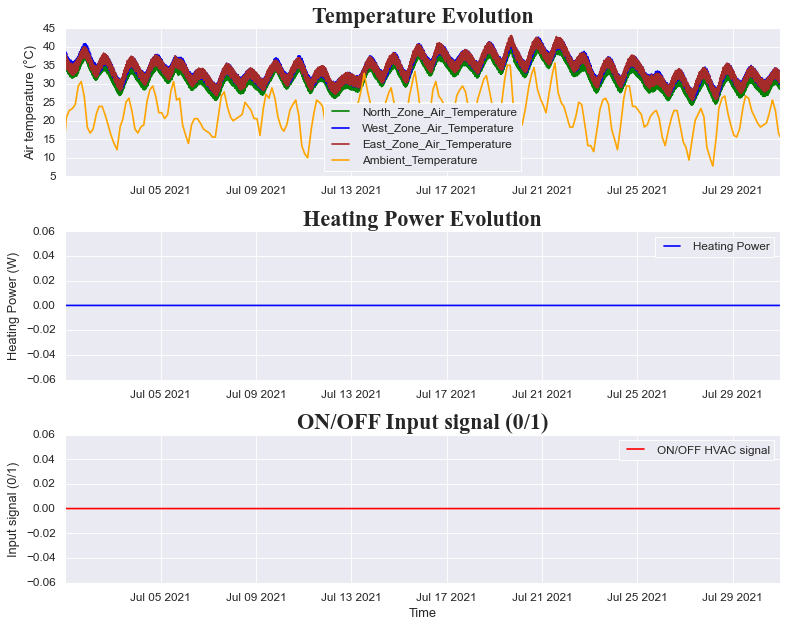

In [553]:
#######################################################################################################################################################################################################
#######################################################################################################################################################################################################
# Plotting the results from the simulation
#######################################################################################################################################################################################################
#######################################################################################################################################################################################################


# load simulation data
df=pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\eplusout.csv",
               parse_dates=[0],
               index_col=[0],
               date_parser=parse_energyplus_datetime_string
              )

rename_dict = {
    "NORTH ZONE:Zone Air Temperature [C](TimeStep)": "North_Zone_Air_Temperature", 
    "WEST ZONE:Zone Air Temperature [C](TimeStep)": "West_Zone_Air_Temperature", 
    "EAST ZONE:Zone Air Temperature [C](TimeStep)": "East_Zone_Air_Temperature", 
    "Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)": "Ambient_Temperature", 
    "MAIN HEATING COIL 1:Heating Coil Heating Rate [W](TimeStep)": "Heating_Power", 
    "ZONE3TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z1",
    "ZONE1TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z2",
    "ZONE2TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z3",
    "NORTH ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "North_Zone_Solar_Rate",
    "NORTH ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "North_Zone_Solar_Energy",
    "WEST ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "West_Zone_Solar_Rate",
    "WEST ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "West_Zone_Solar_Energy",
    "EAST ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "East_Zone_Solar_Rate",
    "EAST ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "East_Zone_Solar_Energy",
    "Date/Time": "Time"
}





df.rename(columns=rename_dict, inplace=True)
time_steps = np.arange(len(df))
df['time_steps'] = time_steps


minutes_to_plot = 2592000  # Define the number of minutes to plot

# Ensure that we have enough data to plot 200 minutes
if len(df) > minutes_to_plot:
    plot_data = df.iloc[:minutes_to_plot]
else:
    plot_data = df  # Not enough data, use what we have

# create and modify Heating Input column
df['Heating Input'] = df['Heating_Power'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z1'] = df['Heating_Power_Z1'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z2'] = df['Heating_Power_Z2'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z3'] = df['Heating_Power_Z3'].apply(lambda x: 1 if x > 0 else 0).astype(int)

# Format the current date and time
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

# Specify the path and filename and save the DataFrame to a new CSV file
file_path =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation"
filename = f"{file_path}imulation_results_{timestamp}.csv"
filename2 = r'D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\Indoor_Temperatures2.csv'
# Specify the file path

df.to_csv(filename, index=False)
df.to_csv(filename2, index=False)


fig, axs = plt.subplots(3, 1, figsize=(10, 8), tight_layout=True)
minutes_to_plot = 2592000   # Define the number of minutes to plot

# Ensure that we have enough data to plot 200 minutes
if len(df) > minutes_to_plot:
    plot_data = df.iloc[:minutes_to_plot]
else:
    plot_data = df  # Not enough data, use what we have

# Plot T_int1, T_int2, T_int3, T_ext
for temp, color in zip(['North_Zone_Air_Temperature', 'West_Zone_Air_Temperature', 'East_Zone_Air_Temperature', 'Ambient_Temperature'], ['green', 'blue', 'brown', 'orange']):
    axs[0].plot(plot_data.index, plot_data[temp], color=color, linewidth=1.5, label=temp)
axs[0].set(ylabel='Temperature (°C)')
axs[0].legend(loc='best')
axs[0].set_ylabel('Air temperature (°C)')
axs[0].set_title('Temperature Evolution', fontname="Times New Roman", size=20, fontweight="bold")

# Plot P_hea1
axs[1].plot(plot_data.index, plot_data['Heating_Power'], color='blue', linewidth=1.5, label='Heating Power')
axs[1].set(ylabel='Heating Power (W)')
axs[1].legend(loc='best')
axs[1].set_ylabel('Heating Power (W)')
axs[1].set_title('Heating Power Evolution', fontname="Times New Roman", size=20, fontweight="bold")

# Plot P_hea2
axs[2].plot(plot_data.index, plot_data['Heating Input'], color='red', linewidth=1.5, label='ON/OFF HVAC signal')
axs[2].set(xlabel='Time', ylabel='P_hea2')
axs[2].legend(loc='best')
axs[2].set_ylabel('Input signal (0/1)')
axs[2].set_title('ON/OFF Input signal (0/1)', fontname="Times New Roman", size=20, fontweight="bold")

plt.show()

plt.show()

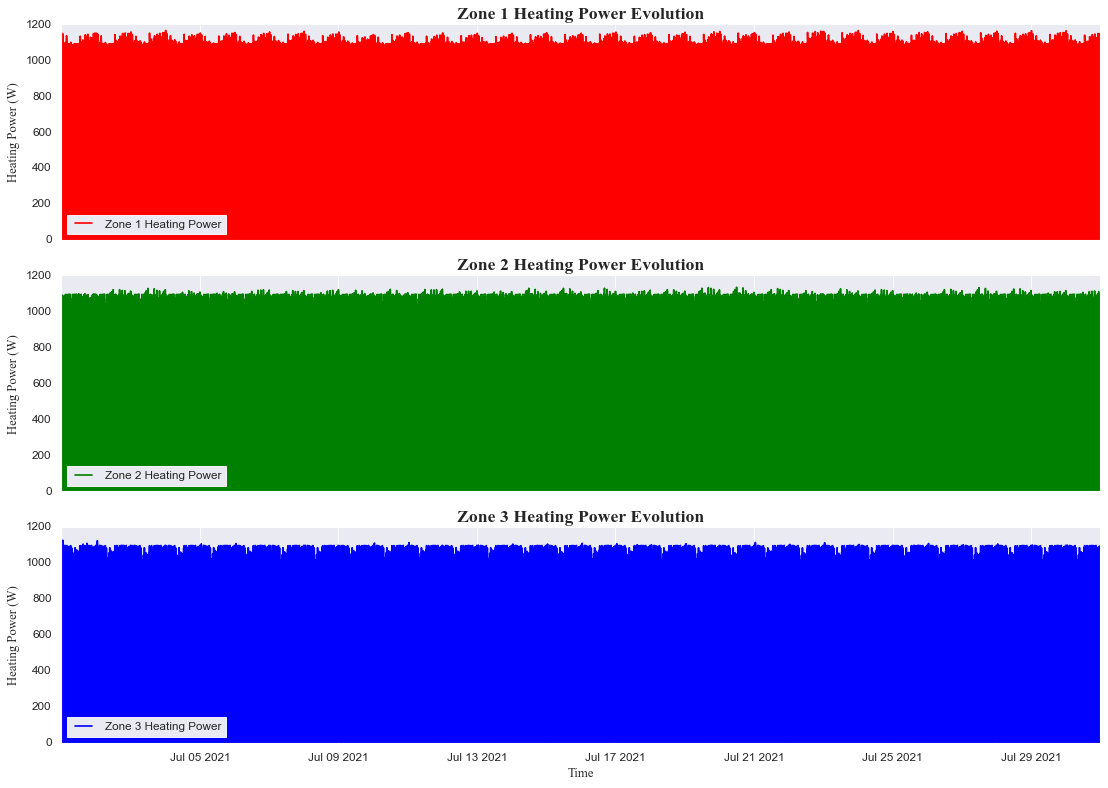

In [554]:
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
# Plot for Zone 1
axs[0].plot(df.index, df['Heating_Power_Z1'], color='red', linewidth=1.5, label='Zone 1 Heating Power')
axs[0].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[0].legend(loc='best')
axs[0].set_title('Zone 1 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")

# Plot for Zone 2
axs[1].plot(df.index, df['Heating_Power_Z2'], color='green', linewidth=1.5, label='Zone 2 Heating Power')
axs[1].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[1].legend(loc='best')
axs[1].set_title('Zone 2 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")

# Plot for Zone 3
axs[2].plot(df.index, df['Heating_Power_Z3'], color='blue', linewidth=1.5, label='Zone 3 Heating Power')
axs[2].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[2].set_xlabel('Time', fontname="Times New Roman")
axs[2].legend(loc='best')
axs[2].set_title('Zone 3 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")

plt.tight_layout()
plt.show()

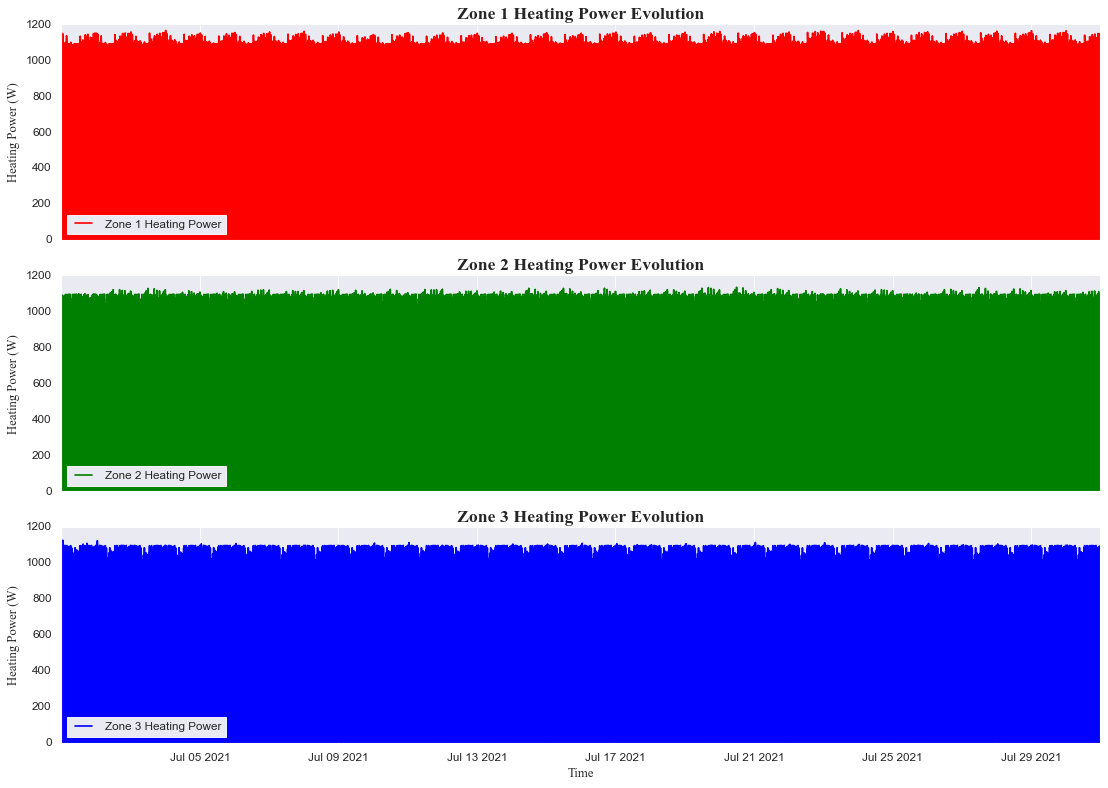

In [555]:
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot for Zone 1
axs[0].plot(df.index, df['Heating_Power_Z1'], color='red', linewidth=1.5, label='Zone 1 Heating Power')
axs[0].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[0].legend(loc='best')
axs[0].set_title('Zone 1 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")
axs[0].set_ylim(bottom=0)

# Plot for Zone 2
axs[1].plot(df.index, df['Heating_Power_Z2'], color='green', linewidth=1.5, label='Zone 2 Heating Power')
axs[1].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[1].legend(loc='best')
axs[1].set_title('Zone 2 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")
axs[1].set_ylim(bottom=0)

# Plot for Zone 3
axs[2].plot(df.index, df['Heating_Power_Z3'], color='blue', linewidth=1.5, label='Zone 3 Heating Power')
axs[2].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[2].set_xlabel('Time', fontname="Times New Roman")
axs[2].legend(loc='best')
axs[2].set_title('Zone 3 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")
axs[2].set_ylim(bottom=0)

plt.tight_layout()
plt.show()


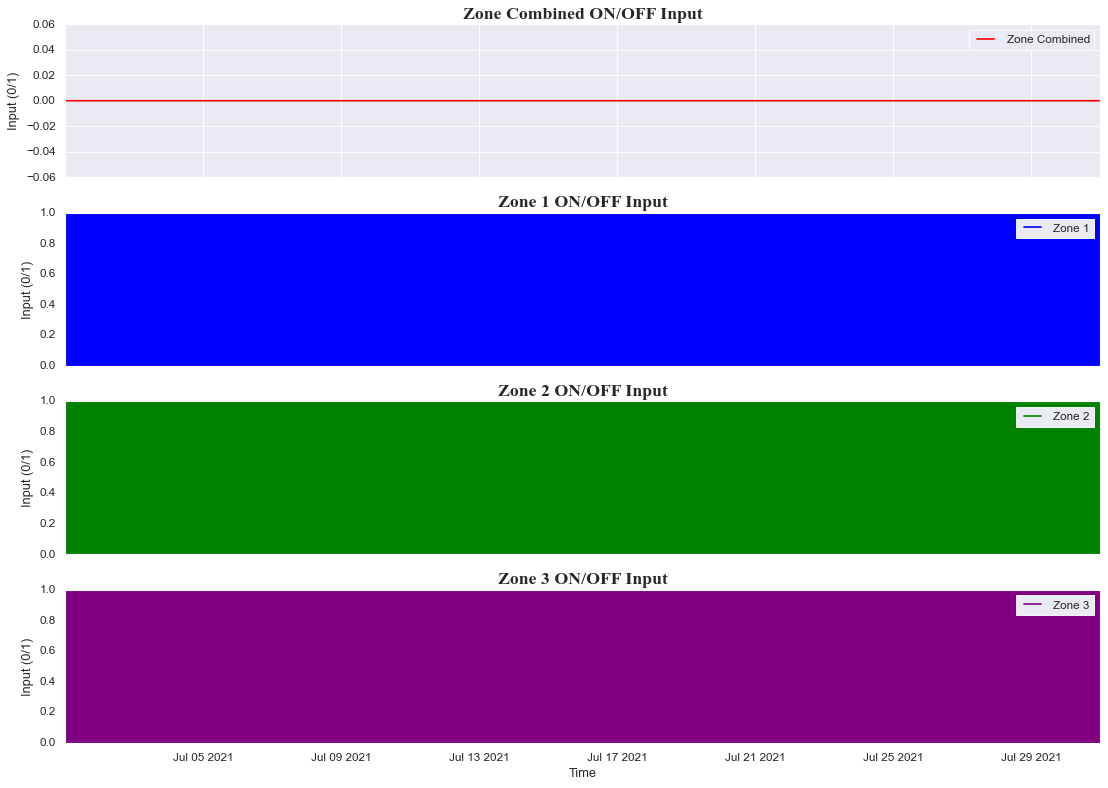

In [556]:

import matplotlib.pyplot as plt

# Create subplots for Heating Input signals
fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Plot for overall Heating Input
axs[0].plot(df.index, df['Heating Input'], color='red', linewidth=1.5, label='Zone Combined')
axs[0].set_ylabel('Input (0/1)')
axs[0].set_title('Zone Combined ON/OFF Input', fontname="Times New Roman", size=16, fontweight="bold")
axs[0].legend(loc='upper right')

# Plot for Zone 1
axs[1].plot(df.index, df['Heating_Input_Z1'], color='blue', linewidth=1.5, label='Zone 1')
axs[1].set_ylabel('Input (0/1)')
axs[1].set_title('Zone 1 ON/OFF Input', fontname="Times New Roman", size=16, fontweight="bold")
axs[1].legend(loc='upper right')

# Plot for Zone 2
axs[2].plot(df.index, df['Heating_Input_Z2'], color='green', linewidth=1.5, label='Zone 2')
axs[2].set_ylabel('Input (0/1)')
axs[2].set_title('Zone 2 ON/OFF Input', fontname="Times New Roman", size=16, fontweight="bold")
axs[2].legend(loc='upper right')

# Plot for Zone 3
axs[3].plot(df.index, df['Heating_Input_Z3'], color='purple', linewidth=1.5, label='Zone 3')
axs[3].set_ylabel('Input (0/1)')
axs[3].set_xlabel('Time')
axs[3].set_title('Zone 3 ON/OFF Input', fontname="Times New Roman", size=16, fontweight="bold")
axs[3].legend(loc='upper right')

plt.tight_layout()
plt.show()

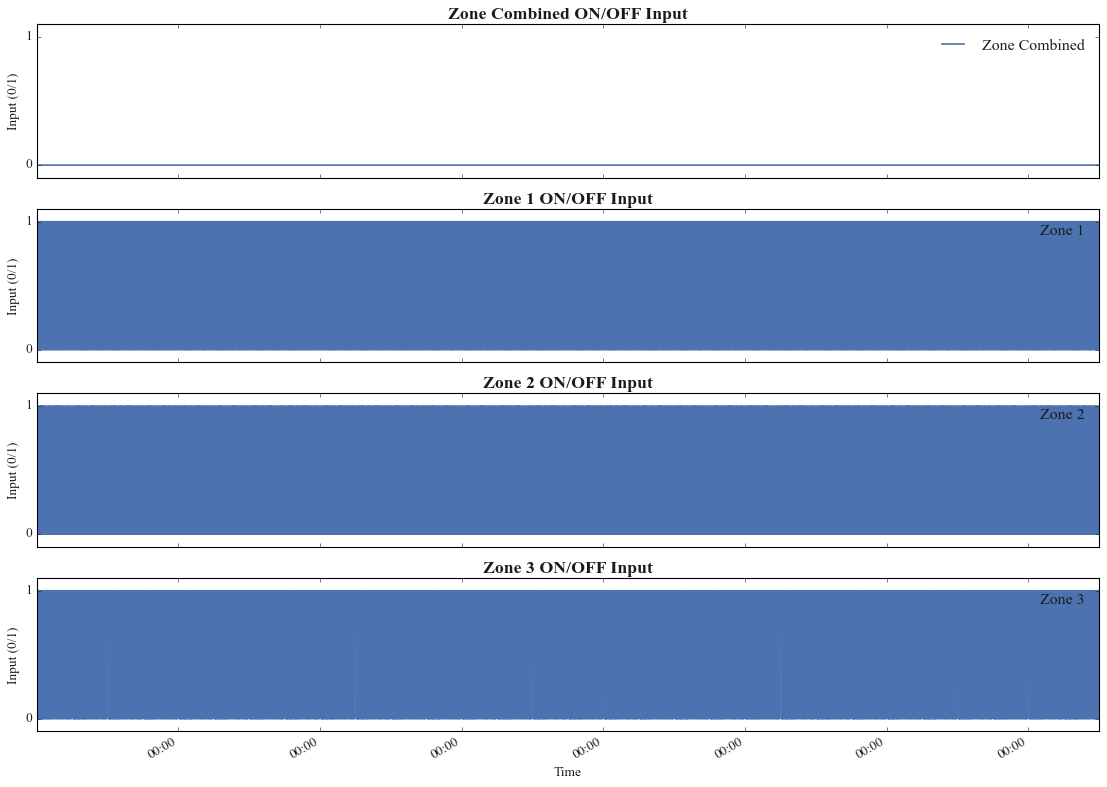

In [557]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates

# --- MATLAB-like look (white bg, classic style) ---
plt.style.use('classic')
mpl.rcParams['figure.facecolor']  = 'white'
mpl.rcParams['axes.facecolor']    = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['axes.edgecolor']    = 'black'
mpl.rcParams['figure.edgecolor']  = 'white'
mpl.rcParams['font.family']       = 'Times New Roman'
mpl.rcParams['axes.grid']         = False  # set True if you want grid lines

# Ensure datetime index (safe)
df.index = pd.to_datetime(df.index)

# Create subplots for Heating Input signals
fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Helper to make ON/OFF axes consistent
def format_onoff(ax):
    ax.set_ylabel('Input (0/1)')
    ax.set_ylim(-0.1, 1.1)
    ax.set_yticks([0, 1])

# Plot for overall Heating Input
axs[0].plot(df.index, df['Heating Input'], linewidth=1.5, label='Zone Combined')
axs[0].set_title('Zone Combined ON/OFF Input', fontsize=16, fontweight='bold')
axs[0].legend(loc='upper right', frameon=False)
format_onoff(axs[0])

# Plot for Zone 1
axs[1].plot(df.index, df['Heating_Input_Z1'], linewidth=1.5, label='Zone 1')
axs[1].set_title('Zone 1 ON/OFF Input', fontsize=16, fontweight='bold')
axs[1].legend(loc='upper right', frameon=False)
format_onoff(axs[1])

# Plot for Zone 2
axs[2].plot(df.index, df['Heating_Input_Z2'], linewidth=1.5, label='Zone 2')
axs[2].set_title('Zone 2 ON/OFF Input', fontsize=16, fontweight='bold')
axs[2].legend(loc='upper right', frameon=False)
format_onoff(axs[2])

# Plot for Zone 3
axs[3].plot(df.index, df['Heating_Input_Z3'], linewidth=1.5, label='Zone 3')
axs[3].set_title('Zone 3 ON/OFF Input', fontsize=16, fontweight='bold')
axs[3].legend(loc='upper right', frameon=False)
format_onoff(axs[3])
axs[3].set_xlabel('Time')

# Nice time formatting on x-axis
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

# Optional: save with white background at high DPI
fig.savefig('heating_inputs_matlab_like.png', dpi=200, bbox_inches='tight')


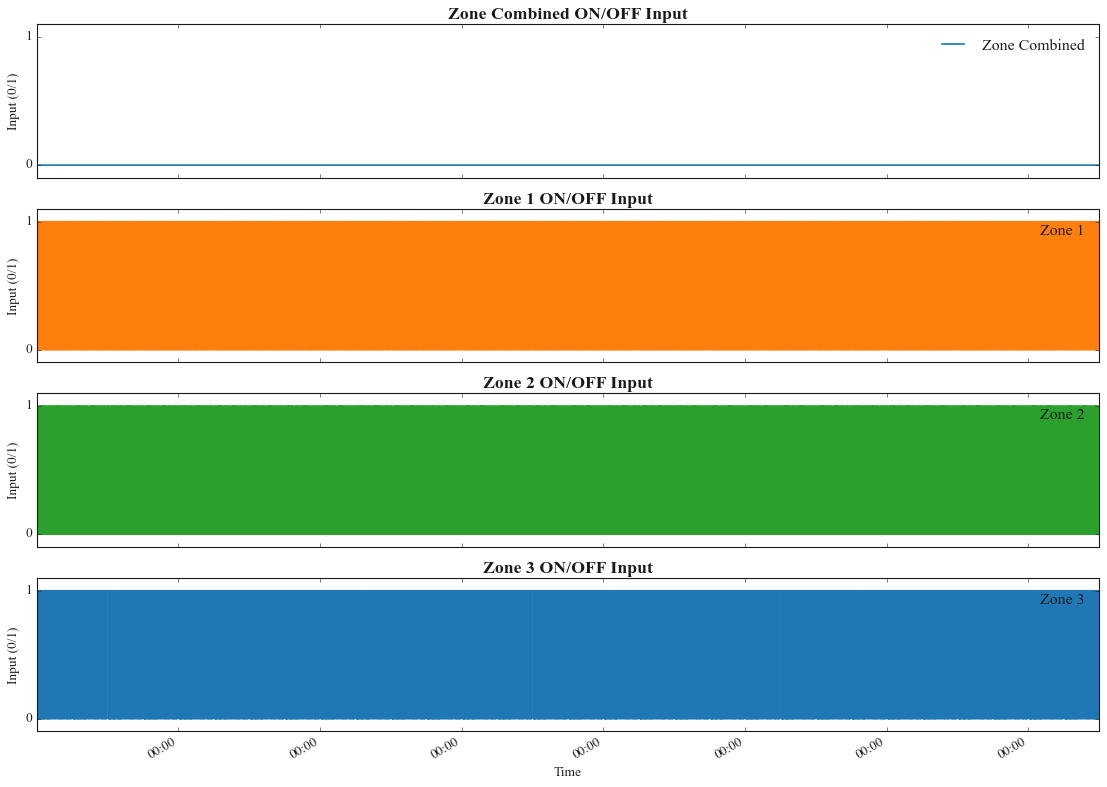

In [558]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates

# --- MATLAB-like look (white bg) ---
plt.style.use('classic')
mpl.rcParams['figure.facecolor']  = 'white'
mpl.rcParams['axes.facecolor']    = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['font.family']       = 'Times New Roman'

# Ensure datetime index
df.index = pd.to_datetime(df.index)

# 3-color palette (Matplotlib defaults: blue, orange, green)
palette = ['#1f77b4', '#ff7f0e', '#2ca02c']  # choose any 3 you like

fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

def format_onoff(ax):
    ax.set_ylabel('Input (0/1)')
    ax.set_ylim(-0.1, 1.1)
    ax.set_yticks([0, 1])

# Combined (color 0)
axs[0].plot(df.index, df['Heating Input'], linewidth=1.5,
            drawstyle='steps-post', label='Zone Combined', color=palette[0])
axs[0].set_title('Zone Combined ON/OFF Input', fontsize=16, fontweight='bold')
axs[0].legend(loc='upper right', frameon=False)
format_onoff(axs[0])

# Z1 (color 1)
axs[1].plot(df.index, df['Heating_Input_Z1'], linewidth=1.5,
            drawstyle='steps-post', label='Zone 1', color=palette[1])
axs[1].set_title('Zone 1 ON/OFF Input', fontsize=16, fontweight='bold')
axs[1].legend(loc='upper right', frameon=False)
format_onoff(axs[1])

# Z2 (color 2)
axs[2].plot(df.index, df['Heating_Input_Z2'], linewidth=1.5,
            drawstyle='steps-post', label='Zone 2', color=palette[2])
axs[2].set_title('Zone 2 ON/OFF Input', fontsize=16, fontweight='bold')
axs[2].legend(loc='upper right', frameon=False)
format_onoff(axs[2])

# Z3 (reuse color 0)
axs[3].plot(df.index, df['Heating_Input_Z3'], linewidth=1.5,
            drawstyle='steps-post', label='Zone 3', color=palette[0])
axs[3].set_title('Zone 3 ON/OFF Input', fontsize=16, fontweight='bold')
axs[3].legend(loc='upper right', frameon=False)
format_onoff(axs[3])
axs[3].set_xlabel('Time')

axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()


In [440]:
import matplotlib.pyplot as plt

# Make sure index is datetime
df.index = pd.to_datetime(df.index)

# Select 1 day (adjust date as needed)
one_day = df.loc['2021-6-3']

# Plot
fig, axs = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Zone 1
axs[0].plot(one_day.index, one_day['Heating_Power_Z1'], color='red', linewidth=1.5, label='Zone 1 Heating Power')
axs[0].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[0].legend(loc='upper right')
axs[0].set_title('Zone 1 Heating Power (, 2021)', fontname="Times New Roman", fontsize=14, fontweight="bold")

# Zone 2
axs[1].plot(one_day.index, one_day['Heating_Power_Z2'], color='green', linewidth=1.5, label='Zone 2 Heating Power')
axs[1].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[1].legend(loc='upper right')
axs[1].set_title('Zone 2 Heating Power (, 2021)', fontname="Times New Roman", fontsize=14, fontweight="bold")

# Zone 3
axs[2].plot(one_day.index, one_day['Heating_Power_Z3'], color='blue', linewidth=1.5, label='Zone 3 Heating Power')
axs[2].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[2].set_xlabel('Time', fontname="Times New Roman")
axs[2].legend(loc='upper right')
axs[2].set_title('Zone 3 Heating Power (, 2021)', fontname="Times New Roman", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


KeyError: '2021-6-3'

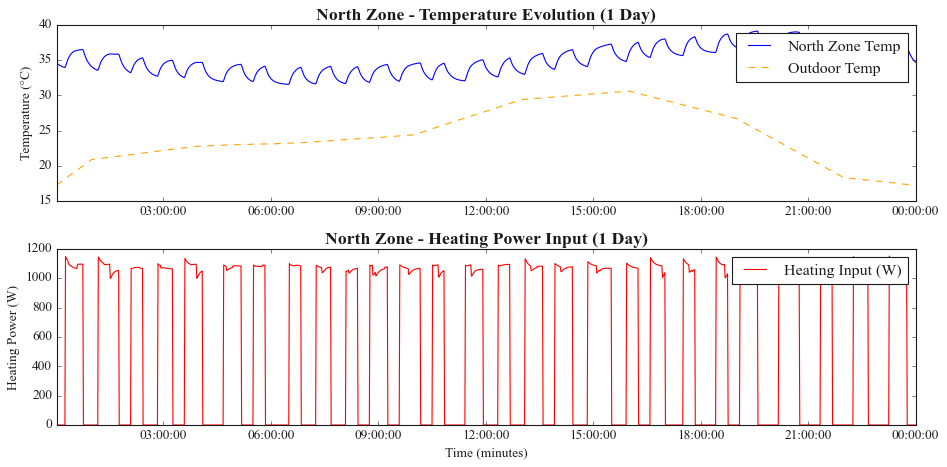

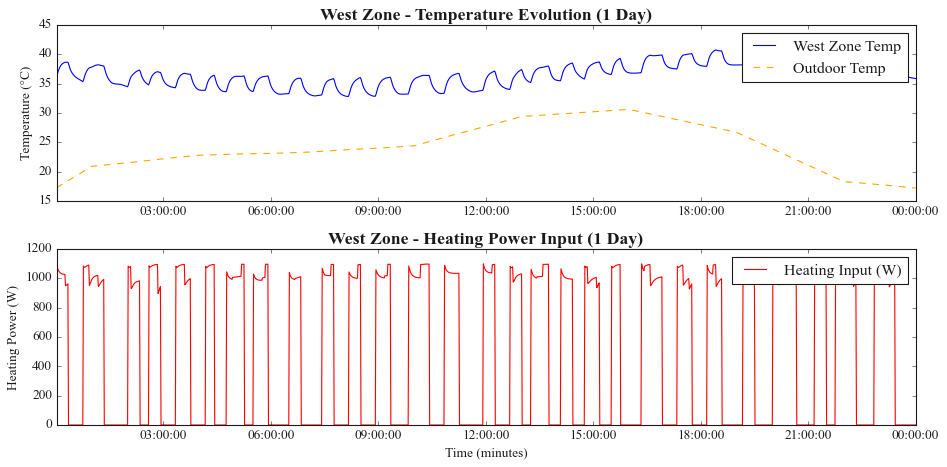

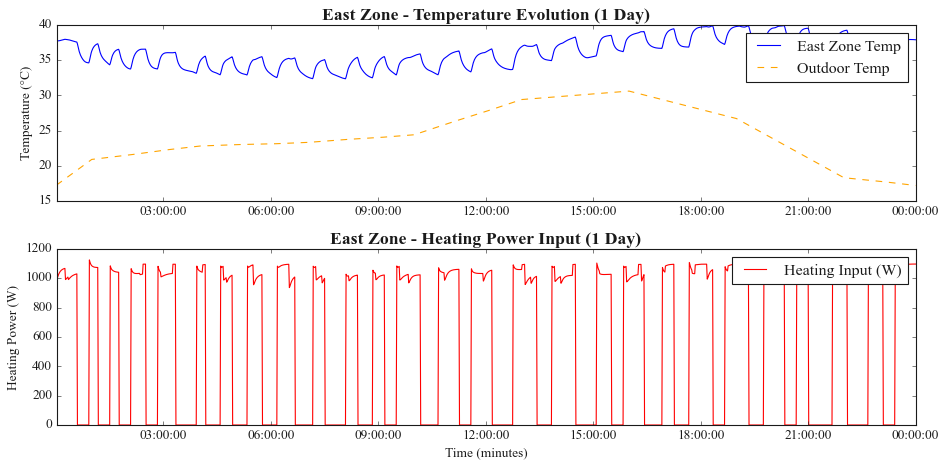

In [559]:
import matplotlib.pyplot as plt

# Define how many minutes = 1 day
minutes_in_one_day = 1440  

# Ensure data is long enough/
if len(df) >= minutes_in_one_day:
    day_data = df.iloc[:minutes_in_one_day]
else:
    day_data = df  # Use what we have



zones = [
    ('North_Zone_Air_Temperature', 'Heating_Power_Z1', 'North Zone'),
    ('West_Zone_Air_Temperature', 'Heating_Power_Z2', 'West Zone'),
    ('East_Zone_Air_Temperature', 'Heating_Power_Z3', 'East Zone'),
]

for temp_col, power_col, zone_name in zones:
    fig, axs = plt.subplots(2, 1, figsize=(12, 6), tight_layout=True)

    # Temperature subplot
    axs[0].plot(day_data.index, day_data[temp_col], label=f'{zone_name} Temp', color='blue')
    axs[0].plot(day_data.index, day_data['Ambient_Temperature'], label='Outdoor Temp', color='orange', linestyle='--')
    axs[0].set_ylabel('Temperature (°C)')
    axs[0].set_title(f'{zone_name} - Temperature Evolution (1 Day)', fontname="Times New Roman", fontsize=16, fontweight='bold')
    axs[0].legend()

    # Heating power input subplot
    axs[1].plot(day_data.index, day_data[power_col], label='Heating Input (W)', color='red')
    axs[1].set_ylabel('Heating Power (W)')
    axs[1].set_xlabel('Time (minutes)')
    axs[1].set_title(f'{zone_name} - Heating Power Input (1 Day)', fontname="Times New Roman", fontsize=16, fontweight='bold')
    axs[1].legend()

    plt.show()


C1: 4446.3
C2: 1736.3
C3: 3944.8
K12: 267.6
K10: 115.7
K23: 195.1
K20: 3.07614
K30: 49.6
RMSE for Zone 1: 1.32
RMSE for Zone 2: 0.75
RMSE for Zone 3: 0.98
8640
8640
43200


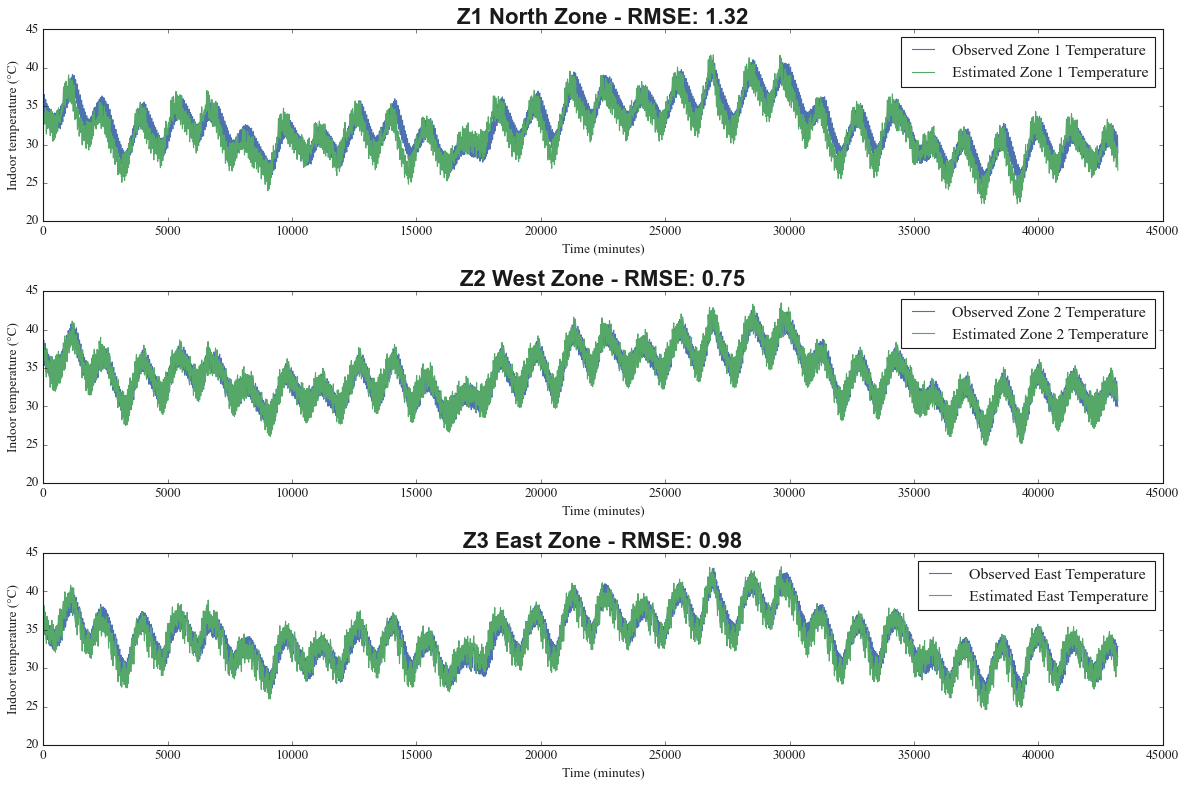

In [560]:

# Load the parameters from CSV file
#parameters_path = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\Parameter_Estimates.csv"
#parameters_df = pd.read_csv(parameters_path)
'''
# Extract the identified parameters
C1 = parameters_df['C1'].values[0]
C2 = parameters_df['C2'].values[0]
C3 = parameters_df['C3'].values[0]
K12 = parameters_df['K12'].values[0]
K10 = parameters_df['K10'].values[0]
K23 = parameters_df['K23'].values[0]
K20 = parameters_df['K20'].values[0]
K30 = parameters_df['K30'].values[0]
'''
#C1  =  6500.0
#C2  =  2708.53074865442
#C3  =  14685.8219174825
#K12 =  387.49751157417643
#K10 =  300.71672918968085
#K23 =  106.61162090281734
#K20 =  20.0
#K30 =  97.6245196026192
#D1  =  0.3
#D2  =  1.5414887566287894
# Denver configuration


#10% WINDOWS
#K12 = 767.7
#K23 = 196.6
#K10 = 240.3
#K20 = 0.0
#K30 = 83.4
#C1 = 5526.0
#C2 = 1281.8
#C3 = 4048.8
#D1 = 0.0
#D2 = 1.6

#OFFSHCEDULE WINDOWS
#K12 = 725.5
#K23 = 194.3
#K10 = 231.0
#K20 = 0.0
#K30 = 86.5
#C1 = 5493.9
#C2 = 1326.2
#C3 = 4069.1
#D1 = 0
#D2 = 2.107592904066596

#Open `100%windows
#K12 = 827.7
#K23 = 197.7
#K10 = 272.8
#K20 = 60.2
#K30 = 64.3
#C1 = 5503.3
#C2 = 1130.7
#C3 = 4036.1
#D1 = 0.0
#D2 = 0.0

#july month 10%
#K12 = 267.0
#K23 = 146.4
#K10 = 89.9
#K20 = 41.7
#K30 = 48.1
#C1 = 3933.7
#C2 = 2121.2
#C3 = 5295.9
#D1 = 5.8547202812626115e-24
#D2 = 0.6957880553777965


#july fully window opn
#K12 = 183.1
#K23 = 139.2
#K10 = 102.8
#K20 = 93.0
#K30 = 29.9
#C1 = 4568.5
#C2 = 1942.8
#C3 = 5176.6
#D1 = 2.465190328815662e-32
#D2 = 1.232595164407831e-31

#july window 10% 0 angle
#K12 = 230.3
#K23 = 192.4
#K10 = 114.9
#K20 = 9.0
#K30 = 54.7
#C1 = 4097.1
#C2 = 1783.2
#C3 = 4015.3
#D1 = 1.7367561689345796e-26
#D2 = 0.04612226272218201

#bellingham
#K12 = 209.8
#K23 = 192.3
#K10 = 120.3
#K20 = 6.7
#K30 = 53.8
#C1 = 4206.1
#C2 = 1807.4
#C3 = 4036.8
#D1 = 4.40499929475413e-27
#D2 = 0.2256086403923423

#K12 = 247.5  
#K23 = 200.8  
#K10 = 236.3  
#K20 = 26.4  
#K30 = 86  
#C1 = 4100.7  
#C2 = 2187.7  
#C3 = 3750.3  
#D1 = 3.16e-30  
#D2 = 0.556775142

#K12 = 209.8  
#K23 = 192.3  
#K10 = 120.3  
#K20 = 6.7  
#K30 = 53.8  
#C1 = 4206.1  
#C2 = 1807.4  
#C3 = 4036.8  
#D1 = 4.40499929475413e-27  
#D2 = 0.2256086403923423

#K12 = 267.2
#K23 = 195.0
#K10 = 115.7
#K20 = 3.13119
#K30 = 49.6
#C1  = 4446.9
#C2  = 1737.9
#C3  = 3943.3
#D1  = 2.4140144709352824e-14
#D2  = 0.008601262783854525

#K12 = 267.0
#K23 = 195.2
#K10 = 115.6
#K20 = 2.96446
#K30 = 49.7
#C1  = 4450.4
#C2  = 1736.0
#C3  = 3946.2
#D1  = 1.1556691208847352e-14
#D2  = 0.012195131056003491


#K12 = 430.2
#K23 = 163.2
#K10 = 105.6857143
#K20 = 23.48299314
#K30 = 44.7
#C1 = 4575.9
#C2 = 1743.6
#C3 = 5134.5
#D1 = 3.02E-22
#D2 = 1.537838249

#K12 = 267.0
#K23 = 195.1
#K10 = 114.6
#K20 = 0.22528
#K30 = 51.5
#C1 = 4450.6
#C2 = 1721.0
#C3 = 3952.6
#D1 = 2.4140144709352824e-14
#D2 = 0.008601262783854525


K12 = 267.6
K23 = 195.1
K10 = 115.7
K20 = 3.07614
K30 = 49.6
C1 = 4446.3
C2 = 1736.3
C3 = 3944.8
D1 = 1.8723754931378877e-14
D2 = 0.008345934811713711


D3=0





# Print the identified parameters
print(f"C1: {C1}")
print(f"C2: {C2}")
print(f"C3: {C3}")
print(f"K12: {K12}")
print(f"K10: {K10}")
print(f"K23: {K23}")
print(f"K20: {K20}")
print(f"K30: {K30}")

# Load the data for temperature and heating power
#filename =  r"C:\Users\onyej\OneDrive\Desktop\Documents\Experiments Folder\modifiedversion\modifiedversion2\Resultssimulation_results_2024-06-08_02-09-41.csv"
df = pd.read_csv(filename)

# Define time step if not explicitly given (assuming uniform steps)
time = df['time_steps'].values
num_steps = len(time)
dt = np.median(np.diff(time))

# Extracting data
T_outdoor = df['Ambient_Temperature'].values 
zone1 = df['North_Zone_Air_Temperature'].values
zone2 = df['West_Zone_Air_Temperature'].values
zone3 = df['East_Zone_Air_Temperature'].values
U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values


#new radiation power
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values

# Compute temperature derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)

# Calculate the estimated temperatures
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]  # Initial temperature for zone1
estimated_zone2[0] = zone2[0]  # Initial temperature for zone2
estimated_zone3[0] = zone3[0]  # Initial temperature for zone3

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (K12*(zone2[i-1] - estimated_zone1[i-1]) + K10*(T_outdoor[i-1] - estimated_zone1[i-1]) + U1[i-1] + D1*NS1[i-1] )/C1 * dt 
    estimated_zone2[i] = estimated_zone2[i-1] + (K12*(zone1[i-1] - estimated_zone2[i-1]) + K23*(zone3[i-1] - estimated_zone2[i-1]) + K20*(T_outdoor[i-1] - estimated_zone2[i-1]) + U2[i-1] + D2*WS2[i-1] )/C2 * dt 
    estimated_zone3[i] = estimated_zone3[i-1] + (K23*(zone2[i-1] - estimated_zone3[i-1]) + K30*(T_outdoor[i-1] - estimated_zone3[i-1]) + U3[i-1]  + D3 * ES3[i-1])/C3 * dt 
    
# Recalculate RMSE for the sliced data
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")

minutes_to_plot = 8640

# Ensure that we have enough data to plot 200 minutes
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    # Not enough data, use what we have
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3

   
# Create a DataFrame
plot_T_outdoor = T_outdoor[:minutes_to_plot] if len(time) > minutes_to_plot else T_outdoor

data = {
    'Time': plot_time,
    'Observed_Temperature_Zone_1': plot_zone1,
    'Estimated_Temperature_Zone_1': plot_estimated_zone1,
    'Observed_Temperature_Zone_2': plot_zone2,
    'Estimated_Temperature_Zone_2': plot_estimated_zone2,
    'Observed_Temperature_Zone_3': plot_zone3,
    'Estimated_Temperature_Zone_3': plot_estimated_zone3,
    'Outdoor_Tmperature': plot_T_outdoor
}

print(len(plot_time))
print(len(plot_zone1))
print(len(T_outdoor))
df = pd.DataFrame(data)

# Save to CSV
df.to_csv(r'D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\validation.csv', index=False)









plt.figure(figsize=(15, 10))

# North Zone
plt.subplot(3, 1, 1)
plt.plot(time, zone1, label='Observed Zone 1 Temperature')
plt.plot(time, estimated_zone1, label='Estimated Zone 1 Temperature')
#plt.plot(time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"Z1 North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(time, zone2, label='Observed Zone 2 Temperature')
plt.plot(time, estimated_zone2, label='Estimated Zone 2 Temperature')
#plt.plot(time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"Z2 West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(time, zone3, label='Observed East Temperature')
plt.plot(time, estimated_zone3, label='Estimated East Temperature')
#plt.plot(time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"Z3 East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()


In [561]:
samples_per_day = int(round(1440 / dt))

n_days = len(zone1) // samples_per_day

z1_obs_daily = zone1[:n_days * samples_per_day].reshape(n_days, samples_per_day)
z2_obs_daily = zone2[:n_days * samples_per_day].reshape(n_days, samples_per_day)
z3_obs_daily = zone3[:n_days * samples_per_day].reshape(n_days, samples_per_day)

z1_est_daily = estimated_zone1[:n_days * samples_per_day].reshape(n_days, samples_per_day)
z2_est_daily = estimated_zone2[:n_days * samples_per_day].reshape(n_days, samples_per_day)
z3_est_daily = estimated_zone3[:n_days * samples_per_day].reshape(n_days, samples_per_day)

daily_rmse_z1 = np.sqrt(np.mean((z1_obs_daily - z1_est_daily)**2, axis=1))
daily_rmse_z2 = np.sqrt(np.mean((z2_obs_daily - z2_est_daily)**2, axis=1))
daily_rmse_z3 = np.sqrt(np.mean((z3_obs_daily - z3_est_daily)**2, axis=1))

print("Zone 1: RMSE =", np.mean(daily_rmse_z1), ", sigma_RMSE =", np.std(daily_rmse_z1), ", RMSE_max =", np.max(daily_rmse_z1))
print("Zone 2: RMSE =", np.mean(daily_rmse_z2), ", sigma_RMSE =", np.std(daily_rmse_z2), ", RMSE_max =", np.max(daily_rmse_z2))
print("Zone 3: RMSE =", np.mean(daily_rmse_z3), ", sigma_RMSE =", np.std(daily_rmse_z3), ", RMSE_max =", np.max(daily_rmse_z3))

Zone 1: RMSE = 1.2847185559647436 , sigma_RMSE = 0.31316836424081723 , RMSE_max = 1.8500505578433495
Zone 2: RMSE = 0.7441151986976963 , sigma_RMSE = 0.04501412824782599 , RMSE_max = 0.8341535102376354
Zone 3: RMSE = 0.9710350773956192 , sigma_RMSE = 0.11642909400451255 , RMSE_max = 1.2381112545650597


In [573]:
import pandas as pd
import os

# =========================================================
# Input/output
# =========================================================
input_csv = filename          # same variable used in your code
output_csv = "usable_columns_for_this_code.csv"

# =========================================================
# Read original file
# =========================================================
df = pd.read_csv(input_csv)

# =========================================================
# Find usual time/date column if available
# =========================================================
datetime_col = None
possible_time_cols = [
    "Date/Time", "Date_Time", "datetime", "Datetime", "date_time",
    "Timestamp", "timestamp", "Time", "time", "time_steps"
]

for col in possible_time_cols:
    if col in df.columns:
        datetime_col = col
        break

# =========================================================
# Columns used by this code
# =========================================================
required_cols = [
    "Ambient_Temperature",
    "North_Zone_Air_Temperature",
    "West_Zone_Air_Temperature",
    "East_Zone_Air_Temperature",
    "Heating_Power_Z1",
    "Heating_Power_Z2",
    "Heating_Power_Z3",
    "North_Zone_Solar_Rate",
    "West_Zone_Solar_Rate",
    "East_Zone_Solar_Rate",
    "time_steps"
]

missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# =========================================================
# Build export dataframe
# =========================================================
export_df = pd.DataFrame()

# Keep usual time/date
if datetime_col is not None:
    export_df["time_or_date"] = df[datetime_col]
    try:
        export_df["parsed_datetime"] = pd.to_datetime(df[datetime_col], errors="coerce")
    except Exception:
        export_df["parsed_datetime"] = pd.NaT
else:
    export_df["time_or_date"] = df["time_steps"]
    export_df["parsed_datetime"] = pd.NaT

# Keep exact usable variables
export_df["time_steps"] = df["time_steps"]
export_df["Ambient_Temperature"] = df["Ambient_Temperature"]

export_df["North_Zone_Air_Temperature"] = df["North_Zone_Air_Temperature"]
export_df["West_Zone_Air_Temperature"] = df["West_Zone_Air_Temperature"]
export_df["East_Zone_Air_Temperature"] = df["East_Zone_Air_Temperature"]

export_df["Heating_Power_Z1"] = df["Heating_Power_Z1"]
export_df["Heating_Power_Z2"] = df["Heating_Power_Z2"]
export_df["Heating_Power_Z3"] = df["Heating_Power_Z3"]

export_df["North_Zone_Solar_Rate"] = df["North_Zone_Solar_Rate"]
export_df["West_Zone_Solar_Rate"] = df["West_Zone_Solar_Rate"]
export_df["East_Zone_Solar_Rate"] = df["East_Zone_Solar_Rate"]

# =========================================================
# Save CSV
# =========================================================
export_df.to_csv(output_csv, index=False)

print(f"Created file: {os.path.abspath(output_csv)}")
print("Saved columns:")
print(export_df.columns.tolist())
print(export_df.head())

Created file: C:\Users\USER\usable_columns_for_this_code.csv
Saved columns:
['time_or_date', 'parsed_datetime', 'time_steps', 'Ambient_Temperature', 'North_Zone_Air_Temperature', 'West_Zone_Air_Temperature', 'East_Zone_Air_Temperature', 'Heating_Power_Z1', 'Heating_Power_Z2', 'Heating_Power_Z3', 'North_Zone_Solar_Rate', 'West_Zone_Solar_Rate', 'East_Zone_Solar_Rate']
   time_or_date               parsed_datetime  time_steps  \
0             0 1970-01-01 00:00:00.000000000           0   
1             1 1970-01-01 00:00:00.000000001           1   
2             2 1970-01-01 00:00:00.000000002           2   
3             3 1970-01-01 00:00:00.000000003           3   
4             4 1970-01-01 00:00:00.000000004           4   

   Ambient_Temperature  North_Zone_Air_Temperature  West_Zone_Air_Temperature  \
0            17.261667                   34.581948                  36.060392   
1            17.323333                   34.509593                  36.444522   
2            17.3850